In [1]:
import numpy as np
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
ds = xr.open_dataset(Path("/mnt/data2/lverhoef/synthetic_ellipses/train_valid_ds.nc"))
ds

<xarray.Dataset> Size: 1GB
Dimensions:   (sample: 10000, x: 128, y: 128)
Coordinates:
  * x         (x) int32 512B 0 1 2 3 4 5 6 7 ... 120 121 122 123 124 125 126 127
  * y         (y) int32 512B 0 1 2 3 4 5 6 7 ... 120 121 122 123 124 125 126 127
Dimensions without coordinates: sample
Data variables:
    ellipse   (sample, x, y) float64 1GB ...
    maj_len   (sample) float64 80kB ...
    min_len   (sample) float64 80kB ...
    angle     (sample) float64 80kB ...
    center_x  (sample) float64 80kB ...
    center_y  (sample) float64 80kB ...

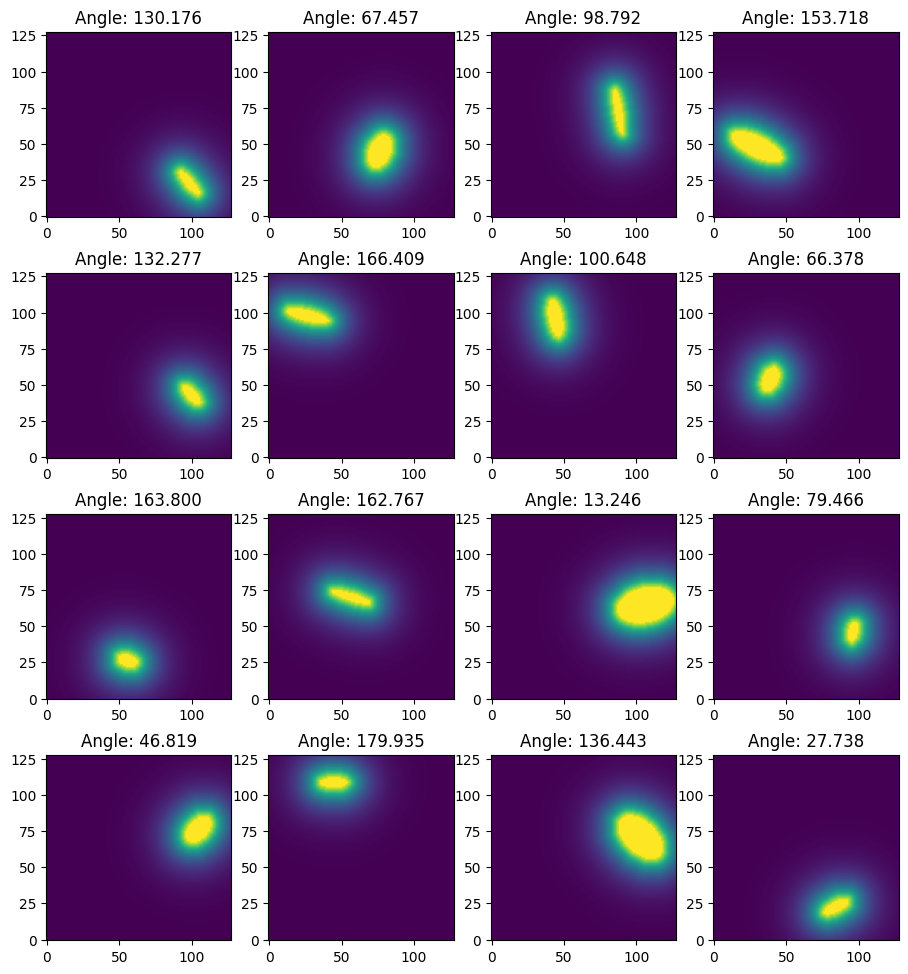

In [3]:
F, ax = plt.subplots(4, 4, figsize=(11, 12))
rng = np.random.default_rng()
sample_indices = rng.integers(0, ds.sizes["sample"], size=(16,))
for i, this_ax in enumerate(np.ravel(ax)):
    this_ax.imshow(ds.ellipse.isel({"sample": sample_indices[i]}), origin="lower")
    this_angle = np.rad2deg(ds.angle.isel({'sample': sample_indices[i]}).values)
    this_ax.set_title(f"Angle: {this_angle:.3f}")

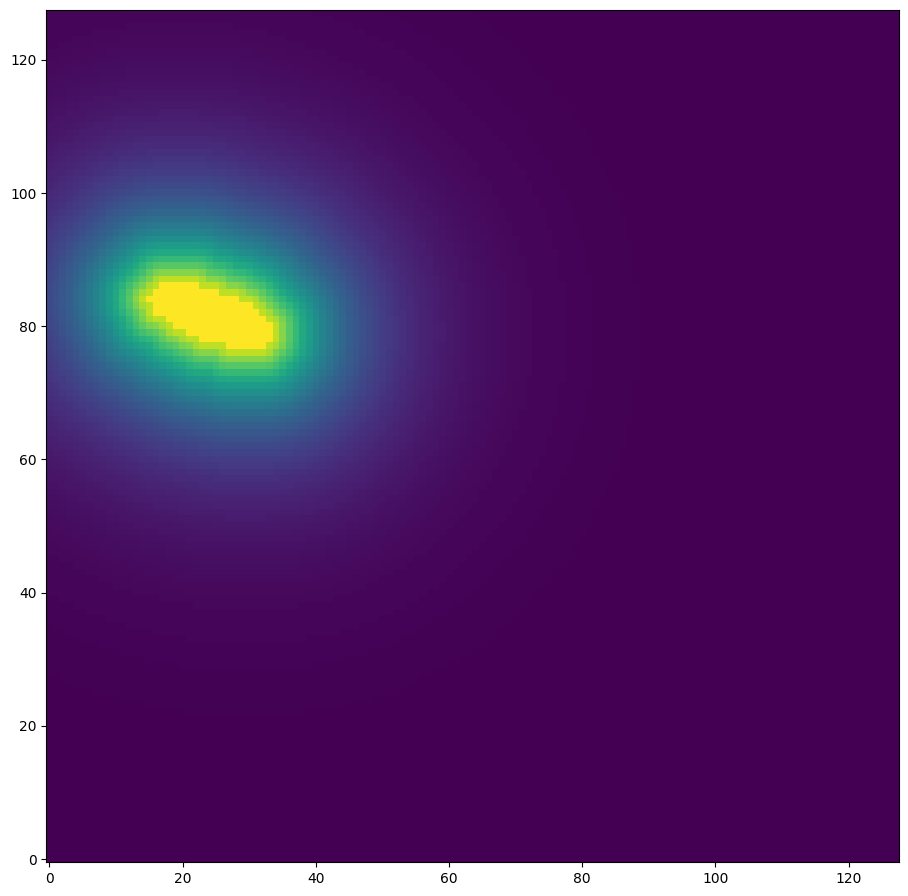

In [6]:
F, ax = plt.subplots(1, 1, figsize=(11, 12))
ax.imshow(ds.ellipse.isel({"sample": 7652}), origin="lower")